In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import mne
import antropy as ant

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import (
    LeaveOneOut, StratifiedKFold, RandomizedSearchCV, 
    cross_val_predict, cross_val_score, KFold
)
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from scipy.stats import pearsonr
from scipy.signal import hilbert

warnings.filterwarnings('ignore')

In [9]:
pasta_features = 'features_extraidas_ec'

df_conectividade = pd.read_csv(os.path.join(pasta_features, 'features_conectividade_beta.csv'))
df_pot_delta_teta = pd.read_csv(os.path.join(pasta_features, 'features_potencia_delta_teta.csv'))
df_rel_psd = pd.read_csv(os.path.join(pasta_features, 'features_rel_psd_delta_alpha.csv'))

# 1. Filtro do DataFrame de Potência: Apenas Delta e Teta/Theta
colunas_psd = [col for col in df_pot_delta_teta.columns if 'Delta' in col or 'Theta' in col or 'Teta' in col or col in ['patient_id', 'pain_score']]
df_pot_delta_teta = df_pot_delta_teta[colunas_psd]

# 2. Filtro do DataFrame de PSD Relativo: Apenas Delta e Alpha/Alfa
colunas_rel = [col for col in df_rel_psd.columns if 'Delta' in col or 'Alpha' in col or 'Alfa' in col or col in ['patient_id', 'pain_score']]
df_rel_psd = df_rel_psd[colunas_rel]

# 1. Cria o df_final fazendo o merge dos dois primeiros DataFrames
df_final = df_conectividade.merge(df_pot_delta_teta, on=['patient_id', 'pain_score'], how='inner')

# 2. Adiciona o terceiro DataFrame ao df_final recém-criado
df_final = df_final.merge(df_rel_psd, on=['patient_id', 'pain_score'], how='inner')

print(f"Total de pacientes no dataset combinado: {df_final.shape[0]}")
print(f"Total de features combinadas (+ 2 colunas de ID/Target): {df_final.shape[1]}")

# Separando o 'X', 'y' e 'feature_names' para rodar no SVM
y = df_final['pain_score'].values

# Removendo o id e o label para sobrar apenas a matriz de features
df_X = df_final.drop(columns=['patient_id', 'pain_score'])

feature_names = df_X.columns.tolist()
X = df_X.values

print(f"Formato da Matriz X combinada: {X.shape}")

Total de pacientes no dataset combinado: 35
Total de features combinadas (+ 2 colunas de ID/Target): 57
Formato da Matriz X combinada: (35, 55)


In [10]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Todas as Features Combinadas'
classifier_name = 'Linear SVM'

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"\nTabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("\nTabela criada com sucesso.")


Tabela já existe. Registros atuais: 24


### Treinamento SVM (LOO) + RFE


Evaluating Linear SVM + RFE — class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Running LOO Nested CV with Linear SVM + RFE...

CLASSIFICATION PERFORMANCE (LOO NESTED CV + LINEAR SVM)
LOO Accuracy: 28.6%
LOO AUC-ROC: 0.138

Best hyperparameters: {'svm_final__C': 0.5}
-------------------------------------------------------

TOP 5 BIOMARKERS (LINEAR SVM + RFE):
  1. PSD_Delta_F3: 34.8% importance
  2. PSD_Delta_C4: 22.4% importance
  3. PSD_Theta_FP2: 20.9% importance
  4. Rel_PSD_Central_Alpha: 14.3% importance
  5. PSD_Delta_P7: 7.6% importance
-------------------------------------------------------

DIREÇÃO DOS TOP 5 BIOMARCADORES:
  1. PSD_Delta_F3: Coeficiente = -0.9645 (-)
     -> Um valor maior neste biomarcador DIMINUI a probabilidade matemática de Dor Severa (Classe 1).
  2. PSD_Delta_C4: Coeficiente = 0.6199 (+)
     -> Um valor maior neste biomarcador AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  3. PSD_Theta_FP2

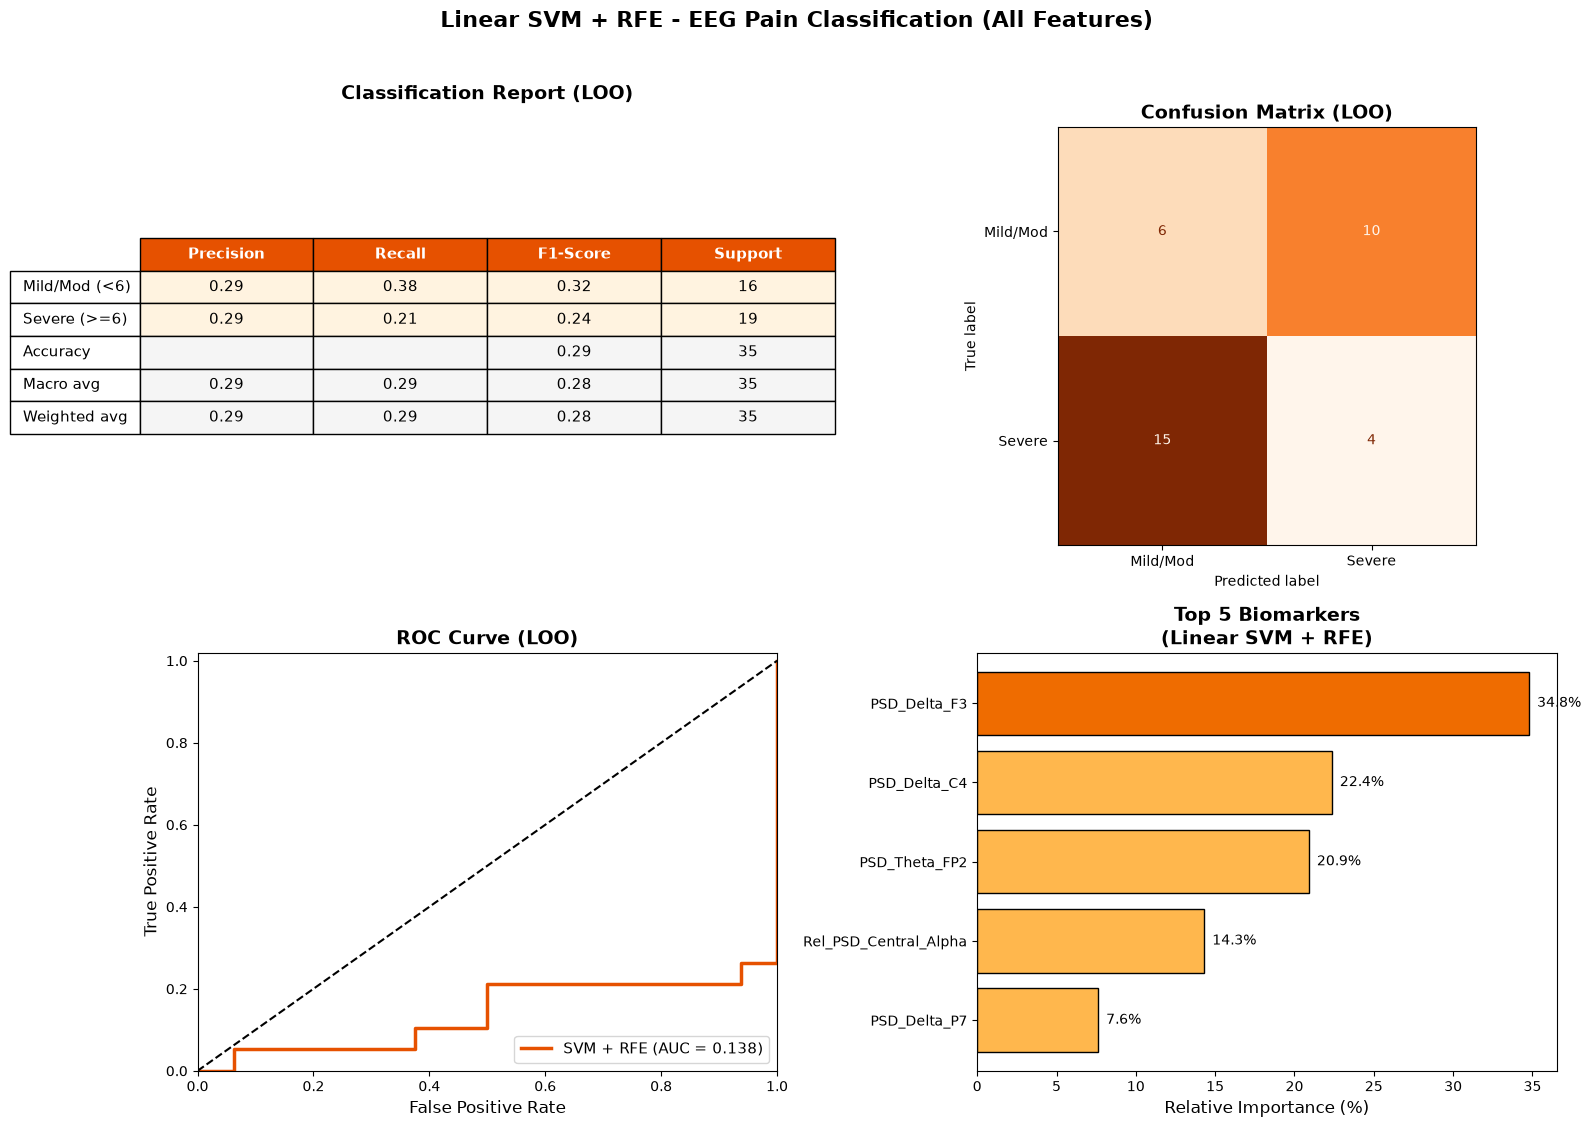


Figure saved as images\svm_linear_rfe_full_results_ec.png
Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [11]:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print("Evaluating Linear SVM + RFE — class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_k = 5

    # Instanciando o SVM Linear para a seleção de features (RFE)
    svm_rfe = SVC(kernel='linear', random_state=42, class_weight='balanced')
    selector_rfe = RFE(estimator=svm_rfe, n_features_to_select=num_k, step=2)

    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', selector_rfe),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Running LOO Nested CV with Linear SVM + RFE...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    y_proba = y_score # Para mapeamento no dicionário de resultados
    
    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV + LINEAR SVM)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treino no dataset completo para extrair a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    
    # Extração dos Biomarcadores selecionados pelo RFE
    mask = search.best_estimator_.named_steps['rfe'].get_support()
    biomarkers = feature_names_filt[mask]

    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARKERS (LINEAR SVM + RFE):")
    for i, idx in enumerate(ranking, 1):
        print(f"  {i}. {biomarkers[idx]}: {importances_pct[idx]:.1f}% importance")

    # --- INÍCIO DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_k} BIOMARCADORES:")
    for i, idx in enumerate(ranking, 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {biomarkers[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Um valor maior neste biomarcador {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO BLOCO DE DIREÇÃO DOS COEFICIENTES ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'SVM + RFE (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    bios_ordered  = biomarkers[ranking]
    scores_ordered = importances_pct[ranking]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Relative Importance (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarkers\n(Linear SVM + RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle('Linear SVM + RFE - EEG Pain Classification (All Features)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'svm_linear_rfe_full_results_ec.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': num_k,
        'Accuracy': round(scores_acc.mean(), 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"Resultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")